# Load Packages

In [4]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical modeling
import statsmodels.api as sm

# Set plotting style
sns.set(style="whitegrid")

# Load Dataset

In [5]:
pbp = pd.read_csv("pbp_clean.csv")

# quick look
pbp.head()

,season,week,game_id,play_type,home_score,away_score
0,2010,1,2010_01_ARI_STL,NaN,13,17
1,2010,1,2010_01_ARI_STL,kickoff,13,17
2,2010,1,2010_01_ARI_STL,pass,13,17
3,2010,1,2010_01_ARI_STL,run,13,17
4,2010,1,2010_01_ARI_STL,pass,13,17


In [6]:
pbp.shape

(721566, 6)

# Dataset Cleaning

In [7]:
# Basic cleaning checks
pbp = pbp.dropna(subset=["season", "week", "game_id"])

# Ensure correct data types
pbp["season"] = pbp["season"].astype(int)
pbp["week"] = pbp["week"].astype(int)

pbp.head()

,season,week,game_id,play_type,home_score,away_score
0,2010,1,2010_01_ARI_STL,NaN,13,17
1,2010,1,2010_01_ARI_STL,kickoff,13,17
2,2010,1,2010_01_ARI_STL,pass,13,17
3,2010,1,2010_01_ARI_STL,run,13,17
4,2010,1,2010_01_ARI_STL,pass,13,17


In [8]:
# Scoring outcome variable 

# final scores/game
game_scores = (
    pbp.groupby(["season", "week", "game_id"])
    .agg({
        "home_score": "max",
        "away_score": "max"
    })
    .reset_index()
)

game_scores["total_points"] = (
    game_scores["home_score"] + game_scores["away_score"]
)

# weekly average points/game
weekly_scoring = (
    game_scores.groupby(["season", "week"])["total_points"]
    .mean()
    .reset_index(name="avg_points")
)

In [9]:
# pass rate outcome variable 

pass_rate = (
    pbp[pbp["play_type"].isin(["pass", "run"])]
    .groupby(["season", "week"])
    .apply(lambda x: (x["play_type"] == "pass").mean())
    .reset_index(name="pass_rate")
)

In [10]:
# plays/game outcome variable 

plays_per_game = (
    pbp.groupby(["season", "week", "game_id"])
    .size()
    .reset_index(name="num_plays")
    .groupby(["season", "week"])["num_plays"]
    .mean()
    .reset_index(name="avg_plays")
)

In [11]:
# merge all variable 

merged = weekly_scoring.merge(pass_rate, on=["season", "week"]) \
                        .merge(plays_per_game, on=["season", "week"])

merged = merged.sort_values(["season", "week"])
merged["time_index"] = range(len(merged))

merged.head()

,season,week,avg_points,pass_rate,avg_plays,time_index
0,2010,1,36.562500,0.586957,175.062500,0
1,2010,2,41.437500,0.561297,172.312500,1
2,2010,3,43.375000,0.582613,175.187500,2
3,2010,4,41.285714,0.578180,171.714286,3
4,2010,5,45.571429,0.592885,180.714286,4


# EDA

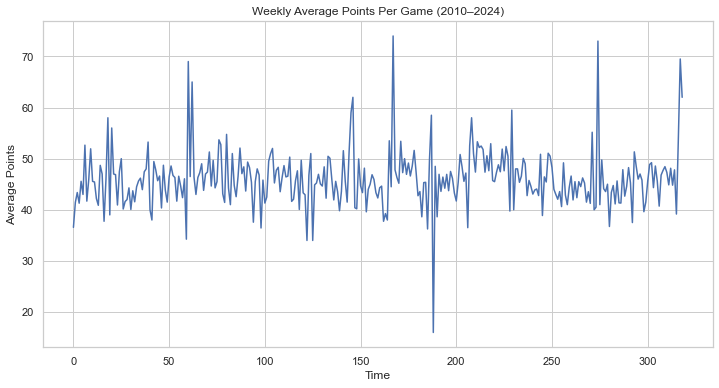

In [12]:
# scoring over time - plot

plt.figure(figsize=(12,6))
plt.plot(merged["avg_points"])
plt.title("Weekly Average Points Per Game (2010–2024)")
plt.xlabel("Time")
plt.ylabel("Average Points")
plt.show()

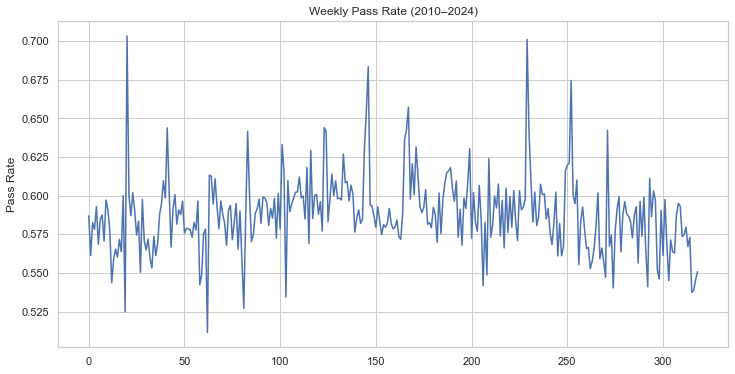

In [13]:
# pass rate - plot

plt.figure(figsize=(12,6))
plt.plot(merged["pass_rate"])
plt.title("Weekly Pass Rate (2010–2024)")
plt.ylabel("Pass Rate")
plt.show()

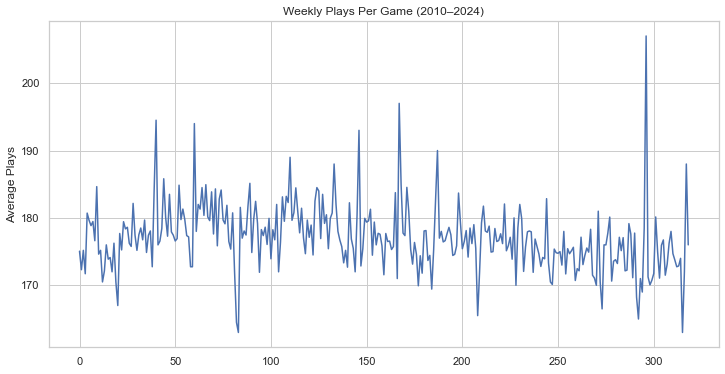

In [14]:
# plays per game - plot

plt.figure(figsize=(12,6))
plt.plot(merged["avg_plays"])
plt.title("Weekly Plays Per Game (2010–2024)")
plt.ylabel("Average Plays")
plt.show()

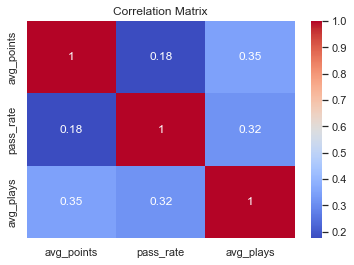

In [15]:
# correlation matrix 

merged[["avg_points", "pass_rate", "avg_plays"]].corr()

# heatmap 

sns.heatmap(
    merged[["avg_points", "pass_rate", "avg_plays"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

## Linear Regression

In [18]:
X = merged[["pass_rate", "avg_plays", "time_index"]]
X = sm.add_constant(X)
y = merged["avg_points"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             avg_points   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     17.84
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.02e-10
Time:                        10:34:50   Log-Likelihood:                -980.17
No. Observations:                 319   AIC:                             1968.
Df Residuals:                     315   BIC:                             1983.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -37.5709     11.627     -3.231      0.0

In [17]:
merged.to_csv("nfl_weekly_dataset.csv", index=False)

## Logistic Regression

In [19]:
# Create binary variable: 1 = high scoring week, 0 = low scoring week
merged["high_scoring"] = (merged["avg_points"] > merged["avg_points"].median()).astype(int)

# Quick check
merged[["avg_points", "high_scoring"]].head()

,avg_points,high_scoring
0,36.562500,0
1,41.437500,0
2,43.375000,0
3,41.285714,0
4,45.571429,0


In [20]:
import statsmodels.api as sm

X = merged[["pass_rate", "avg_plays", "time_index"]]
X = sm.add_constant(X)

y = merged["high_scoring"]

In [30]:
# test for weekly score balance

merged["high_scoring"].value_counts()

0    161
1    158
Name: high_scoring, dtype: int64

In [31]:
# Logistic Regression model

logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.640664
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           high_scoring   No. Observations:                  319
Model:                          Logit   Df Residuals:                      315
Method:                           MLE   Df Model:                            3
Date:                Wed, 18 Mar 2026   Pseudo R-squ.:                 0.07566
Time:                        10:38:55   Log-Likelihood:                -204.37
converged:                       True   LL-Null:                       -221.10
Covariance Type:            nonrobust   LLR p-value:                 2.580e-07
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -30.0537      5.863     -5.126      0.000     -41.545     -18.562
pass_rate      8.7819      5.

In [32]:
merged["predicted_prob"] = logit_model.predict(X)

merged[["high_scoring", "predicted_prob"]].head()

,high_scoring,predicted_prob
0,0,0.348423
1,0,0.226089
2,0,0.344656
3,0,0.238479
4,0,0.554306


In [33]:
merged["predicted_class"] = (merged["predicted_prob"] > 0.5).astype(int)

# Accuracy
accuracy = (merged["predicted_class"] == merged["high_scoring"]).mean()
print("Accuracy:", accuracy)

Accuracy: 0.6269592476489029
